In [1]:
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Bidirectional

*DATASET*

In [2]:
# Load IMDB dataset
num_words = 10000  # Limit vocabulary size
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=num_words)
print(x_train[0])
print(y_train[0])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
1


In [3]:
# Pad sequences to ensure uniform input shape
maxlen = 200       # Max length of a review

x_train = pad_sequences(x_train, maxlen=maxlen, padding='post', truncating='post')
x_test = pad_sequences(x_test, maxlen=maxlen, padding='post', truncating='post')

x_train

array([[   1,   14,   22, ...,  226,   65,   16],
       [   1,  194, 1153, ...,    0,    0,    0],
       [   1,   14,   47, ...,    0,    0,    0],
       ...,
       [   1,   11,    6, ...,    0,    0,    0],
       [   1, 1446, 7079, ...,    0,    0,    0],
       [   1,   17,    6, ...,    0,    0,    0]])

*Define the Model*

In [4]:
# Define the model
model = keras.Sequential([
    keras.layers.Embedding(input_dim=num_words, output_dim=128),
    keras.layers.LSTM(64, return_sequences=False),  # Many-to-one
    keras.layers.Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


# Train the model and store history
history = model.fit(x_train, y_train, epochs=20, batch_size=64, validation_data=(x_test, y_test))

# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

# ✅ Store loss and accuracy for each epoch
train_loss = history.history['loss']  # Stores list of losses per epoch
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 33s 81ms/step - accuracy: 0.5232 - loss: 0.6892 - val_accuracy: 0.5333 - val_loss: 0.6789
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 31s 80ms/step - accuracy: 0.5742 - loss: 0.6682 - val_accuracy: 0.5933 - val_loss: 0.6551
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 75ms/step - accuracy: 0.6844 - loss: 0.5726 - val_accuracy: 0.8191 - val_loss: 0.4056
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 32s 82ms/step - accuracy: 0.8850 - loss: 0.2989 - val_accuracy: 0.8434 - val_loss: 0.3615
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 32s 81ms/step - accuracy: 0.9310 - loss: 0.2015 - val_accuracy: 0.8429 - val_loss: 0.3784
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 35s 89ms/step - accuracy: 0.9573 - loss: 0.1383 - val_accuracy: 0.8420 - val_loss: 0.4507
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 46s 118ms/step - accuracy: 0.9726 - loss: 0.1004 - val_accuracy: 0.8379 - val_loss: 0.4769
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 32s 81ms/step - accuracy: 0.9826 - loss: 0.0697 -

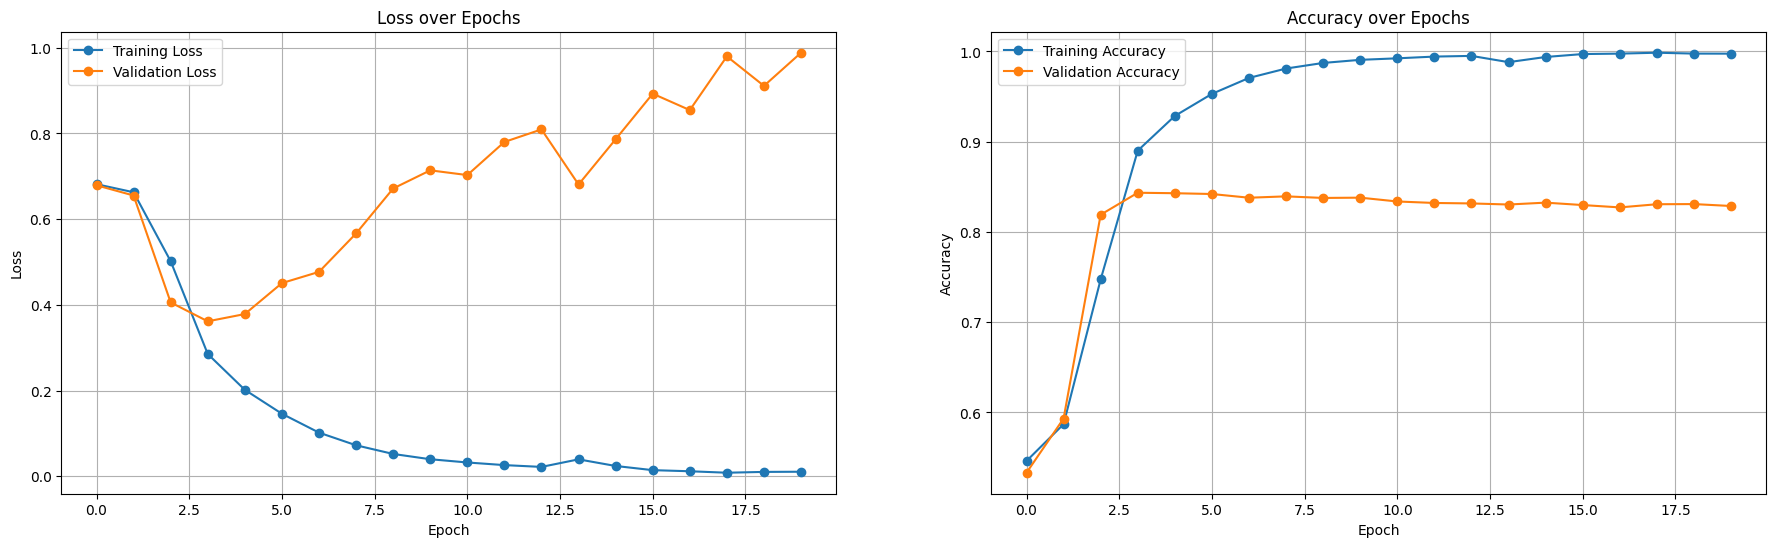

In [5]:
# ✅ Plot training and validation performance
fig, axes = plt.subplots(ncols=2, figsize=(22, 6))

# Loss curve
axes[0].plot(train_loss, label="Training Loss", marker="o")
axes[0].plot(val_loss, label="Validation Loss", marker="o")
axes[0].legend()
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid()

# Accuracy curve
axes[1].plot(train_acc, label="Training Accuracy", marker="o")
axes[1].plot(val_acc, label="Validation Accuracy", marker="o")
axes[1].legend()
axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid()

plt.show()

In [6]:
# Change the model
model = keras.Sequential([
    keras.layers.Embedding(input_dim=num_words, output_dim=64),
    keras.layers.SimpleRNN(64, activation='tanh'),
    keras.layers.Dense(1, activation='sigmoid')  # Binary classification (0 = negative, 1 = positive)
])

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adamw', metrics=['accuracy'])


# Train the model and store history
history = model.fit(x_train, y_train, epochs=20, batch_size=64, validation_data=(x_test, y_test))

# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

# ✅ Store loss and accuracy for each epoch
train_loss = history.history['loss']  # Stores list of losses per epoch
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.4989 - loss: 0.6974 - val_accuracy: 0.5054 - val_loss: 0.6933
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.5225 - loss: 0.6916 - val_accuracy: 0.5023 - val_loss: 0.6970
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.5521 - loss: 0.6845 - val_accuracy: 0.5083 - val_loss: 0.6998
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.5921 - loss: 0.6524 - val_accuracy: 0.5429 - val_loss: 0.7332
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.6380 - loss: 0.6039 - val_accuracy: 0.6686 - val_loss: 0.6301
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.8103 - loss: 0.4154 - val_accuracy: 0.7882 - val_loss: 0.4718
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.9155 - loss: 0.2225 - val_accuracy: 0.7585 - val_loss: 0.5807
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.9453 - loss: 0.1522 - 

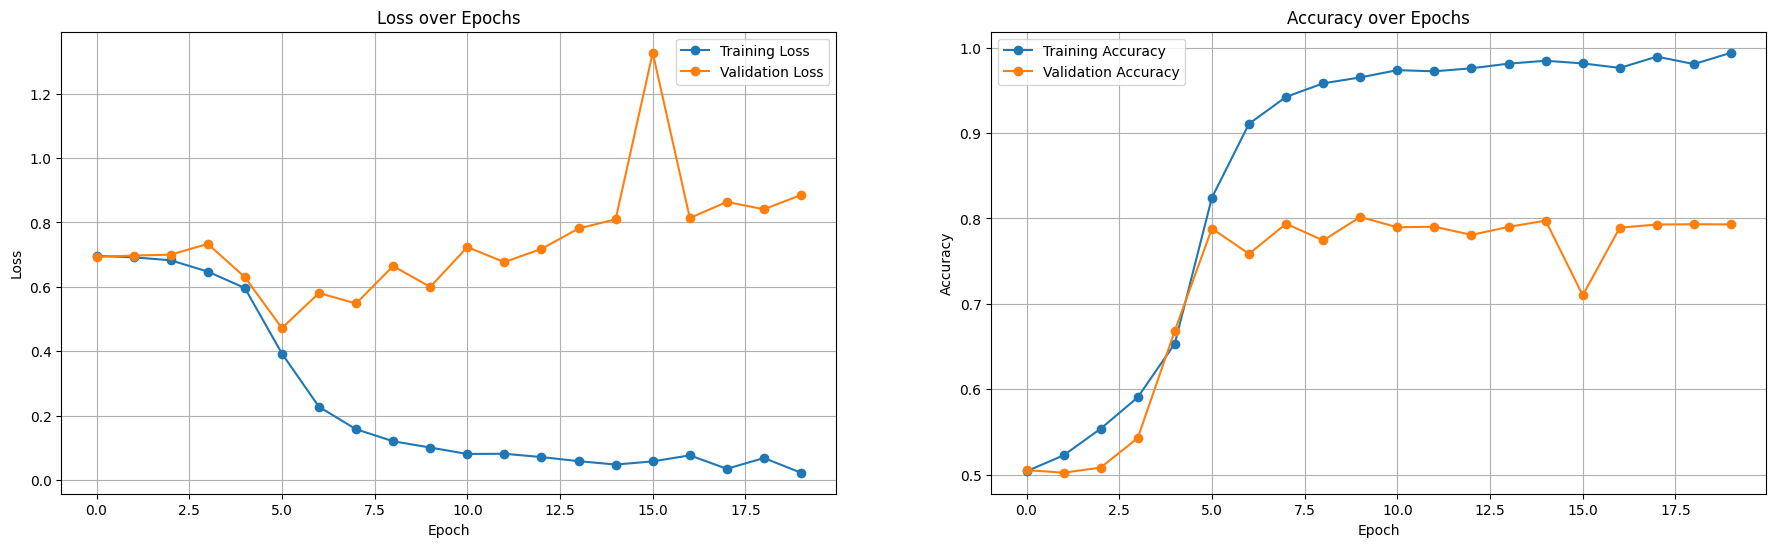

In [7]:
# ✅ Plot training and validation performance
fig, axes = plt.subplots(ncols=2, figsize=(22, 6))

# Loss curve
axes[0].plot(train_loss, label="Training Loss", marker="o")
axes[0].plot(val_loss, label="Validation Loss", marker="o")
axes[0].legend()
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid()

# Accuracy curve
axes[1].plot(train_acc, label="Training Accuracy", marker="o")
axes[1].plot(val_acc, label="Validation Accuracy", marker="o")
axes[1].legend()
axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid()

plt.show()

In [8]:
# Modify the model
model = keras.Sequential([
    keras.layers.Embedding(input_dim=num_words, output_dim=128),
    Bidirectional(keras.layers.LSTM(128, activation='tanh', return_sequences=False)),
    keras.layers.Dropout(0.5),  # Add dropout to avoid overfitting
    keras.layers.Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the model with a tuned optimizer
optimizer = keras.optimizers.Adam(learning_rate=0.0005)  # Adjust learning rate
model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# Add early stopping to stop training once performance plateaus
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model and store history
history = model.fit(x_train, y_train, epochs=20, batch_size=64, validation_data=(x_test, y_test), callbacks=[early_stopping])

# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

# Store loss and accuracy for each epoch
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 84s 210ms/step - accuracy: 0.6317 - loss: 0.6050 - val_accuracy: 0.8432 - val_loss: 0.3619
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 109s 279ms/step - accuracy: 0.8904 - loss: 0.2863 - val_accuracy: 0.8431 - val_loss: 0.3612
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 79s 203ms/step - accuracy: 0.9183 - loss: 0.2212 - val_accuracy: 0.8507 - val_loss: 0.3608
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 82s 209ms/step - accuracy: 0.9384 - loss: 0.1771 - val_accuracy: 0.8420 - val_loss: 0.3999
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 91s 232ms/step - accuracy: 0.9485 - loss: 0.1471 - val_accuracy: 0.8403 - val_loss: 0.4445
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 100s 255ms/step - accuracy: 0.9625 - loss: 0.1120 - val_accuracy: 0.8358 - val_loss: 0.5059
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.8498 - loss: 0.3595
Test Accuracy: 0.8507


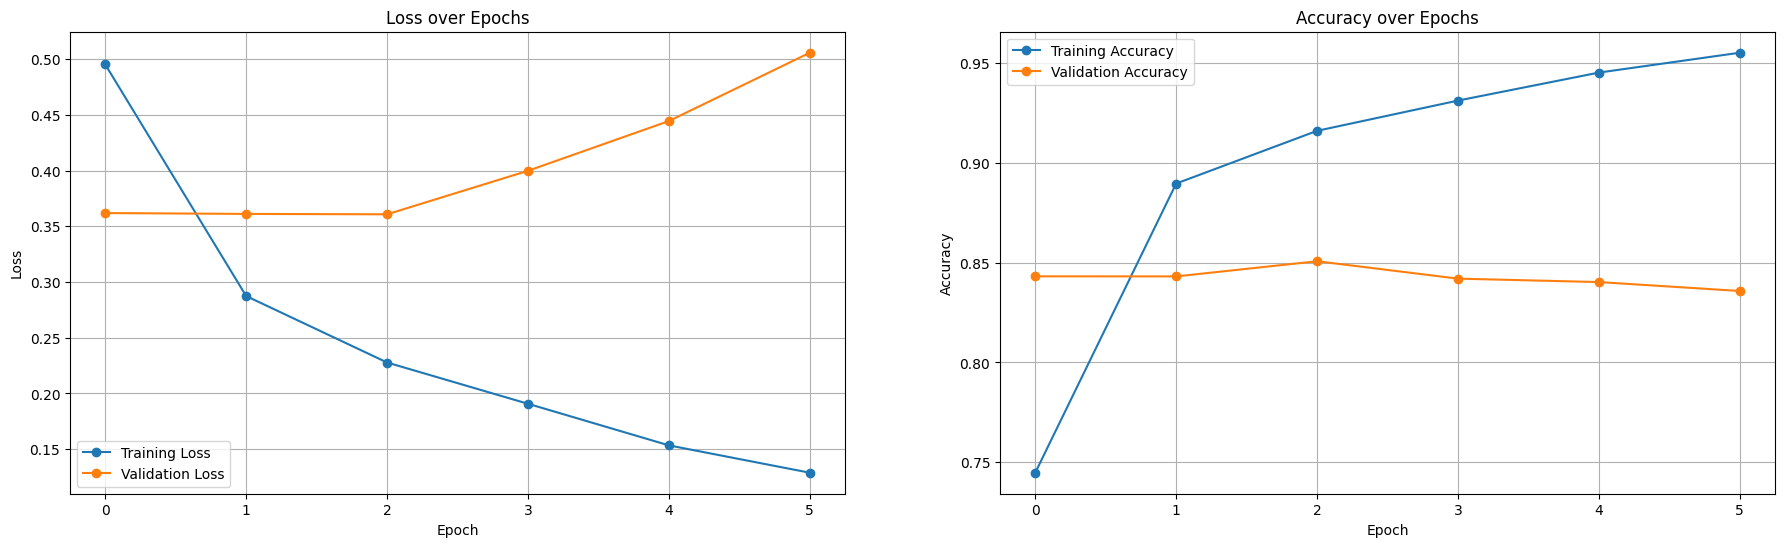

In [9]:
# ✅ Plot training and validation performance
fig, axes = plt.subplots(ncols=2, figsize=(22, 6))

# Loss curve
axes[0].plot(train_loss, label="Training Loss", marker="o")
axes[0].plot(val_loss, label="Validation Loss", marker="o")
axes[0].legend()
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid()

# Accuracy curve
axes[1].plot(train_acc, label="Training Accuracy", marker="o")
axes[1].plot(val_acc, label="Validation Accuracy", marker="o")
axes[1].legend()
axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid()

plt.show()

**Model 1: LSTM (Many-to-one)**

Architecture: Embedding layer (128 output dimensions), LSTM layer (64 units), Dense layer (1 unit, sigmoid activation).

Optimizer: Adam

Performance: Achieved high training accuracy (close to 100%) but significant overfitting is evident. The validation accuracy plateaus around 83-84% and the validation loss increases drastically after a few epochs, indicating the model is memorizing the training data and not generalizing well.

Test accuracy is 82.88%.

Strengths: Simple LSTM architecture. Learns quickly initially.

Weaknesses: Severe overfitting. Validation performance is significantly lower than training performance. The model is not robust.

**Model 2: SimpleRNN**

Architecture: Embedding layer (64 output dimensions), SimpleRNN layer (64 units, tanh activation), Dense layer (1 unit, sigmoid activation).

Optimizer: AdamW

Performance: Training accuracy reaches close to 100% but again, the validation accuracy is much lower, topping out around 80%. The validation loss is also quite high and erratic. This model also overfits, though perhaps slightly less severely than Model 1.

Test accuracy is 79.30%.

Strengths: Simpler and faster training than LSTM.

Weaknesses: Overfitting, less effective at capturing long-range dependencies in text compared to LSTMs. Lower overall performance than Model 1.

**Model 3: Bidirectional LSTM with Dropout and Early Stopping**

Architecture: Embedding layer (128 output dimensions), Bidirectional LSTM layer (128 units, tanh activation), Dropout layer (50%), Dense layer (1 unit, sigmoid activation).

Optimizer: Adam (learning rate 0.0005)

Performance: Achieves a validation accuracy of 85.07% before early stopping kicks in. The training also shows overfitting.
The test accuracy is 85.07% which is the best among the three models.

Strengths: Bidirectional LSTM can capture context from both past and future words. Dropout helps regularize the model and reduce overfitting. Early stopping prevents the model from continuing to train when it is no longer improving on the validation set. Best performance of the three.

Weaknesses: More complex architecture, longer training time per epoch. Still exhibits some signs of overfitting, although it's better managed than the other two models.

**Conclusion:**

Model 3, the Bidirectional LSTM with dropout and early stopping, performs the best overall, achieving the highest validation and test accuracy.  It demonstrates the benefits of a more sophisticated architecture, regularization techniques, and careful hyperparameter tuning. While it still shows signs of overfitting, it's significantly better controlled than the other two. Model 1 overfits very badly and Model 2, while faster, does not perform as well as the LSTM variants.  For this task, the added complexity of the bidirectional LSTM is worthwhile.